In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("car data.csv")

print(df.head())
print(df.shape)

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)


In [3]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [4]:
current_year = 2026

df['Car_Age'] = current_year - df['Year']

In [5]:
df.drop('Year', axis=1, inplace=True)

In [6]:
df = pd.get_dummies(df,
                    columns=['Fuel_Type',
                             'Selling_type',
                             'Transmission'],
                    drop_first=True)

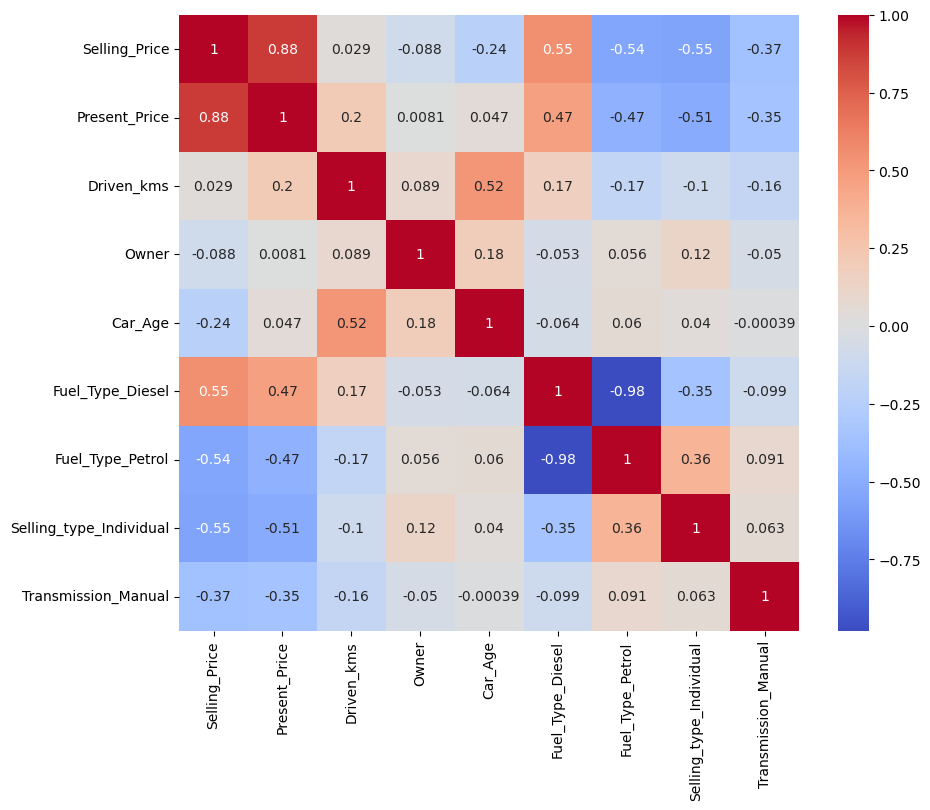

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

In [8]:
X = df.drop(['Selling_Price', 'Car_Name'],
            axis=1)

y = df['Selling_Price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)

In [12]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9594566919773236


In [13]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.6368655737704919


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.9664050903676592


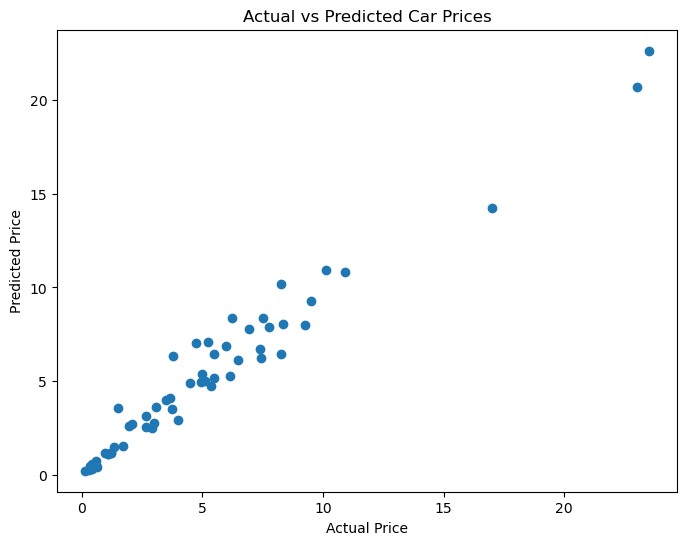

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

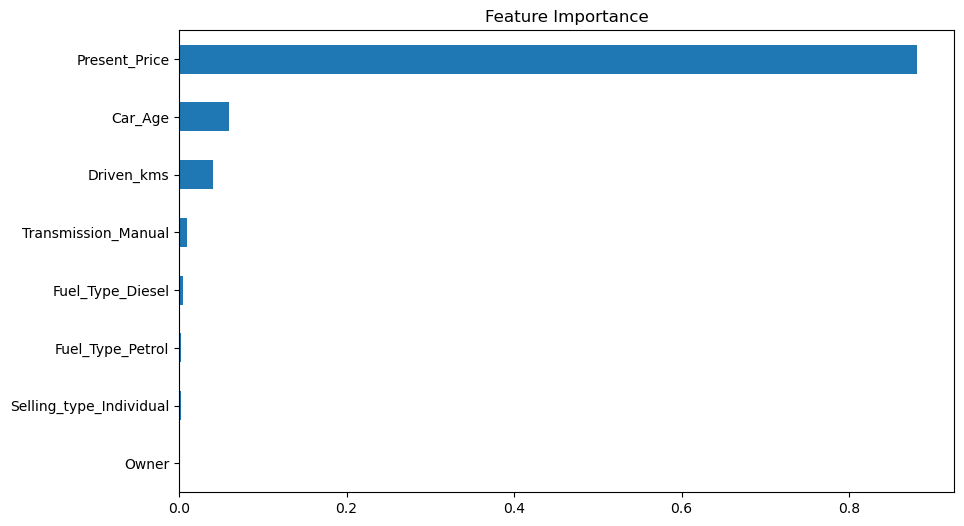

In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

In [17]:
import pickle

model = pickle.load(open("car_price_model.pkl", "rb"))